In [ ]:
import numpy as np
from scipy.optimize import minimize

# Данные варианта 13 
X = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])


def paraboloid_model(xy, a, b, x0, y0, c):
    x, y = xy
    return a * (x - x0) ** 2 + b * (y - y0) ** 2 + c


def loss_mse(params, X, Y, Z):
    # Распаковка параметров оптимизации
    a, b, x0, y0, c = params
    z_pred = paraboloid_model((X, Y), a, b, x0, y0, c)
    return np.mean((z_pred - Z) ** 2)


# Начальное приближение 
initial_guess = [1.0, 1.0, 3.0, 3.0, 0.0]

# Важно: args передает дополнительные параметры в loss_mse
res = minimize(loss_mse, initial_guess, args=(X, Y, Z), method="L-BFGS-B")

print(f"Оптимальные параметры параболоида: {res.x}")

Оптимальные параметры параболоида: [-4.75559831e-02 -1.12423560e+00  7.45001685e+01 -5.56251889e-02
  2.57259637e+02]


Оптимальные параметры: a=-0.0520, b=-1.1638, x0=76.7247, y0=-0.3238, c=299.1722
Невязки на объектах: [ 0.04537199 -0.0184548  -0.2902859   0.43483716 -0.17293101]


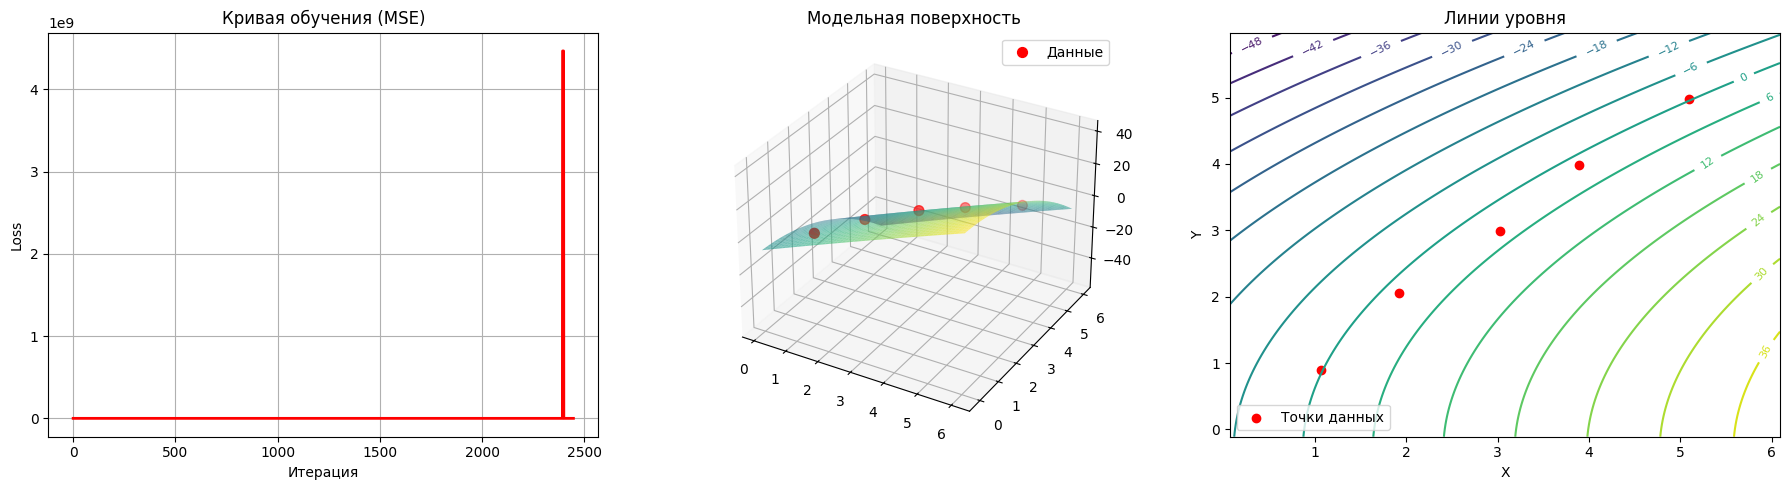

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Данные Варианта 13
data = np.array(
    [
        [1.07, 0.89, -0.18],
        [1.92, 2.05, 1.69],
        [3.03, 2.99, 4.31],
        [3.89, 3.98, 1.36],
        [5.09, 4.98, -0.20],
    ]
)

X_data = data[:, 0]
Y_data = data[:, 1]
Z_data = data[:, 2]


# 2. Определение модели эллиптического параболоида
def paraboloid_model(xy, a, b, x0, y0, c):
    x, y = xy
    return a * (x - x0) ** 2 + b * (y - y0) ** 2 + c


# Список для хранения истории лосса (кривая обучения)
loss_history = []


def loss_function(params, X, Y, Z):
    z_pred = paraboloid_model((X, Y), *params)
    mse = np.mean((z_pred - Z) ** 2)
    loss_history.append(mse)
    return mse


# 3. Оптимизация
# Начальное приближение: a, b, x0, y0, c
initial_guess = [1.0, 1.0, np.mean(X_data), np.mean(Y_data), np.max(Z_data)]
res = minimize(
    loss_function, initial_guess, args=(X_data, Y_data, Z_data), method="L-BFGS-B"
)

a_opt, b_opt, x0_opt, y0_opt, c_opt = res.x

# 4. Вычисление невязок
z_final_pred = paraboloid_model((X_data, Y_data), *res.x)
residuals = z_final_pred - Z_data

print(
    f"Оптимальные параметры: a={a_opt:.4f}, b={b_opt:.4f}, x0={x0_opt:.4f}, y0={y0_opt:.4f}, c={c_opt:.4f}"
)
print("Невязки на объектах:", residuals)

# 5. Визуализация 
fig = plt.figure(figsize=(18, 5))

# График 1: Кривая обучения
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(loss_history, color="red", lw=2)
ax1.set_title("Кривая обучения (MSE)")
ax1.set_xlabel("Итерация")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Подготовка сетки для поверхностей
x_range = np.linspace(min(X_data) - 1, max(X_data) + 1, 100)
y_range = np.linspace(min(Y_data) - 1, max(Y_data) + 1, 100)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = paraboloid_model((X_mesh, Y_mesh), *res.x)

# График 2: Модельная поверхность и точки данных
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(X_mesh, Y_mesh, Z_mesh, alpha=0.6, cmap="viridis")
ax2.scatter(X_data, Y_data, Z_data, color="red", s=50, label="Данные")
ax2.set_title("Модельная поверхность")
ax2.legend()

# График 3: Линии уровня и точки
ax3 = fig.add_subplot(1, 3, 3)
cp = ax3.contour(X_mesh, Y_mesh, Z_mesh, levels=15, cmap="viridis")
ax3.clabel(cp, inline=True, fontsize=8)
ax3.scatter(X_data, Y_data, color="red", label="Точки данных")
ax3.set_title("Линии уровня")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.legend()

plt.tight_layout()
plt.show()

In [10]:
def rbf_network(xy, params):
    x, y = xy
    # Порядок: w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2
    w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2 = params

    phi1 = np.exp(-b1 * ((x - c1x) ** 2 + (y - c1y) ** 2))
    phi2 = np.exp(-b2 * ((x - c2x) ** 2 + (y - c2y) ** 2))

    return w0 + w1 * phi1 + w2 * phi2


def loss_rbf(params, X, Y, Z):
    z_pred = rbf_network((X, Y), params)
    return np.mean((z_pred - Z) ** 2)


# Центры из Задания 4.1: c1=(1.5, 1.5), c2=(4.0, 4.0)
# Начальные веса w=[0, 1, 1] и бета=0.5
init_params_rbf = [0.0, 1.0, 1.0, 1.5, 1.5, 0.5, 4.0, 4.0, 0.5]

res_rbf = minimize(loss_rbf, init_params_rbf, args=(X, Y, Z), method="L-BFGS-B")

print(f"Оптимальные параметры RBF: {res_rbf.x}")

Оптимальные параметры RBF: [-0.2592886   2.43461995  2.54633488  2.55488218  2.97716366  0.62125671
  2.8827791   3.22571864  0.48116542]


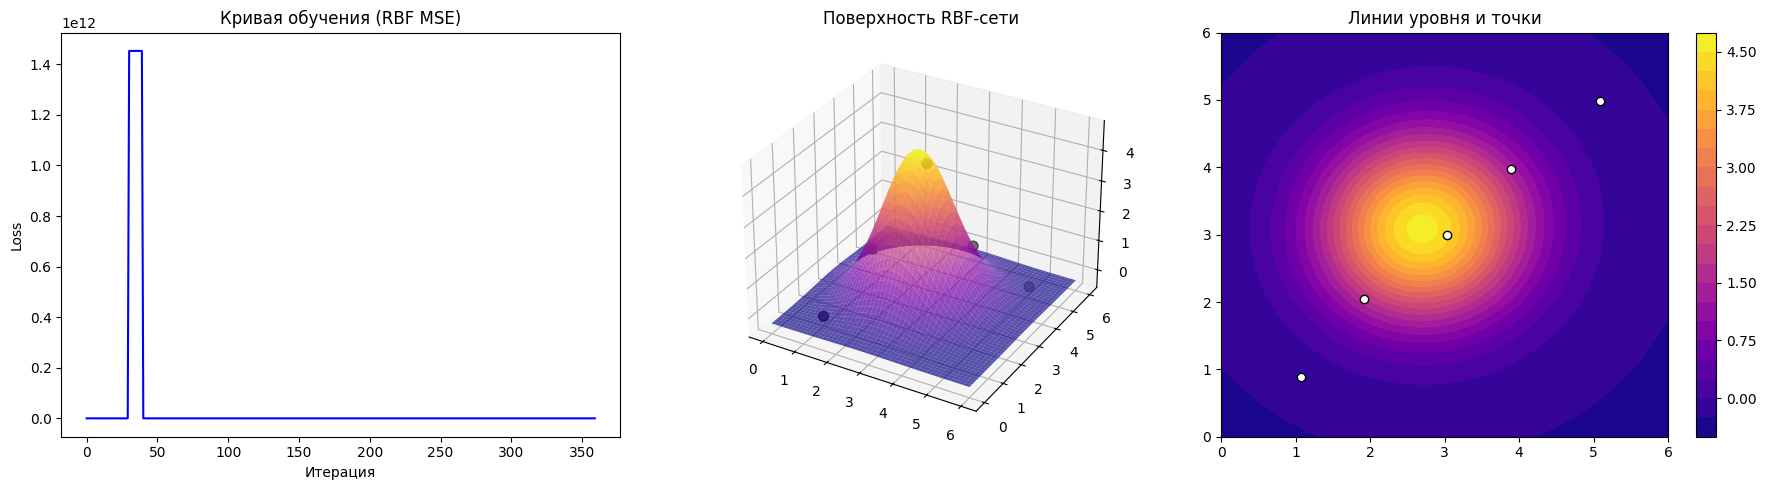

Финальные параметры: [-0.2592886   2.43461995  2.54633488  2.55488218  2.97716366  0.62125671
  2.8827791   3.22571864  0.48116542]
Невязки: [-1.96209721e-05 -1.47552812e-06 -1.74707250e-05 -3.49902437e-05
 -1.18823954e-05]


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Данные Варианта 13 
X_data = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y_data = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z_data = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])


# 2. Определение RBF-сети (2 радиальных нейрона)
def rbf_model(xy, params):
    x, y = xy
    # Параметры: w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2
    w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2 = params

    phi1 = np.exp(-b1 * ((x - c1x) ** 2 + (y - c1y) ** 2))
    phi2 = np.exp(-b2 * ((x - c2x) ** 2 + (y - c2y) ** 2))

    return w0 + w1 * phi1 + w2 * phi2


loss_history = []


def loss_function(params, X, Y, Z):
    z_pred = rbf_model((X, Y), params)
    mse = np.mean((z_pred - Z) ** 2)
    loss_history.append(mse)
    return mse


# 3. Оптимизация (Стратегия 2: обучаем все параметры)
# Начальные значения: центры из задания 4.1, веса 1.0, беты 0.5
initial_params = [0.0, 1.0, 1.0, 1.5, 1.5, 0.5, 4.0, 4.0, 0.5]

res = minimize(
    loss_function, initial_params, args=(X_data, Y_data, Z_data), method="L-BFGS-B"
)


p = res.x

# 4. Расчет невязок
z_final_pred = rbf_model((X_data, Y_data), p)
residuals = z_final_pred - Z_data

# 5. Построение графиков
fig = plt.figure(figsize=(18, 5))

# Кривая обучения
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(loss_history, color="blue")
ax1.set_title("Кривая обучения (RBF MSE)")
ax1.set_xlabel("Итерация")
ax1.set_ylabel("Loss")

# Сетка для поверхностей
x_grid = np.linspace(0, 6, 100)
y_grid = np.linspace(0, 6, 100)
X_m, Y_m = np.meshgrid(x_grid, y_grid)
Z_m = rbf_model((X_m, Y_m), p)

# Поверхность
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(X_m, Y_m, Z_m, cmap="plasma", alpha=0.7)
ax2.scatter(X_data, Y_data, Z_data, color="black", s=50)
ax2.set_title("Поверхность RBF-сети")

# Линии уровня
ax3 = fig.add_subplot(1, 3, 3)
contour = ax3.contourf(X_m, Y_m, Z_m, levels=20, cmap="plasma")
fig.colorbar(contour)
ax3.scatter(X_data, Y_data, color="white", edgecolors="black")
ax3.set_title("Линии уровня и точки")

plt.tight_layout()
plt.show()

print(f"Финальные параметры: {p}")
print(f"Невязки: {residuals}")

--- Задание 2 (Параболоид) ---
Параметры: [-1.55529038e-01 -1.16843074e+00  3.47473654e+01 -1.24227378e+00
  1.81667702e+02]
Невязки: [ 0.13974173 -0.29067535 -0.03224952  0.35091779 -0.16708586]

--- Задание 5 (RBF) ---
Параметры: [-0.2592886   2.43461995  2.54633488  2.55488218  2.97716366  0.62125671
  2.8827791   3.22571864  0.48116542]
Невязки: [-1.96209721e-05 -1.47552812e-06 -1.74707250e-05 -3.49902437e-05
 -1.18823954e-05]


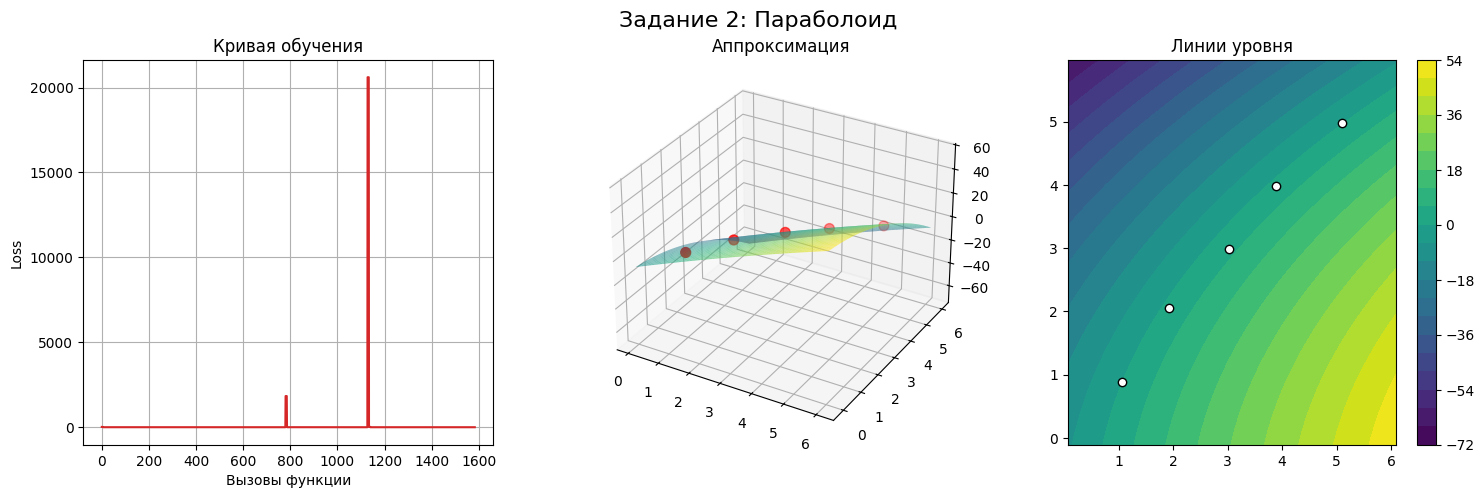

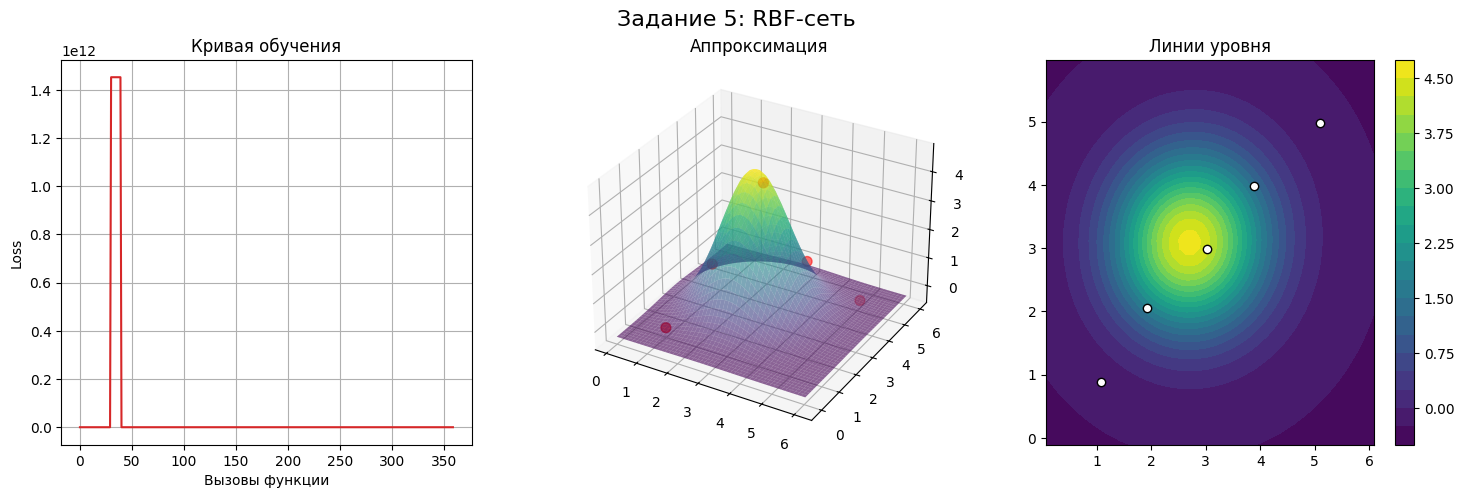

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Данные Варианта 13 [cite: 56-76, 118]
X_data = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y_data = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z_data = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])

# =====================================================
# ЗАДАНИЕ 2: Эллиптический параболоид
# =====================================================


def paraboloid_model(xy, a, b, x0, y0, c):
    x, y = xy
    return a * (x - x0) ** 2 + b * (y - y0) ** 2 + c


loss_history_2 = []


def loss_2(params, X, Y, Z):
    z_pred = paraboloid_model((X, Y), *params)
    mse = np.mean((z_pred - Z) ** 2)
    loss_history_2.append(mse)
    return mse


# Начальное приближение [cite: 111]
# Попробуем чуть смещенные значения, чтобы кривая обучения была наглядной
init_2 = [0.5, 0.5, 3.0, 3.0, 2.0]
res_2 = minimize(loss_2, init_2, args=(X_data, Y_data, Z_data), method="L-BFGS-B")

# =====================================================
# ЗАДАНИЕ 5: RBF-сеть (Стратегия 2) [cite: 131, 138]
# =====================================================


def rbf_model(xy, params):
    x, y = xy
    # w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2
    w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2 = params
    phi1 = np.exp(-b1 * ((x - c1x) ** 2 + (y - c1y) ** 2))
    phi2 = np.exp(-b2 * ((x - c2x) ** 2 + (y - c2y) ** 2))
    return w0 + w1 * phi1 + w2 * phi2


loss_history_5 = []


def loss_5(params, X, Y, Z):
    z_pred = rbf_model((X, Y), params)
    mse = np.mean((z_pred - Z) ** 2)
    loss_history_5.append(mse)
    return mse


# Начальные значения из Задания 4.1 и 4.2 [cite: 134, 135, 138]
init_5 = [0.0, 1.0, 1.0, 1.5, 1.5, 0.5, 4.0, 4.0, 0.5]
res_5 = minimize(loss_5, init_5, args=(X_data, Y_data, Z_data), method="L-BFGS-B")

# =====================================================
# ВИЗУАЛИЗАЦИЯ (Пример для Задания 2)
# =====================================================


def plot_results(title, loss_hist, model_func, params, X_d, Y_d, Z_d):
    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(title, fontsize=16)

    # 1. Кривая обучения
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(loss_hist, color="tab:red", label="MSE")
    ax1.set_title("Кривая обучения")
    ax1.set_xlabel("Вызовы функции")
    ax1.set_ylabel("Loss")
    ax1.grid(True)

    # Подготовка сетки
    x_grid = np.linspace(min(X_d) - 1, max(X_d) + 1, 50)
    y_grid = np.linspace(min(Y_d) - 1, max(Y_d) + 1, 50)
    XX, YY = np.meshgrid(x_grid, y_grid)
    ZZ = model_func((XX, YY), params)

    # 2. Поверхность
    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    ax2.plot_surface(XX, YY, ZZ, cmap="viridis", alpha=0.6)
    ax2.scatter(X_d, Y_d, Z_d, color="red", s=50, label="Data points")
    ax2.set_title("Аппроксимация")

    # 3. Линии уровня
    ax3 = fig.add_subplot(1, 3, 3)
    contour = ax3.contourf(XX, YY, ZZ, levels=20, cmap="viridis")
    plt.colorbar(contour, ax=ax3)
    ax3.scatter(X_d, Y_d, color="white", edgecolors="black")
    ax3.set_title("Линии уровня")

    plt.show()


# Вывод результатов
print("--- Задание 2 (Параболоид) ---")
print(f"Параметры: {res_2.x}")
z_p_pred = paraboloid_model((X_data, Y_data), *res_2.x)
print(f"Невязки: {z_p_pred - Z_data}\n")

print("--- Задание 5 (RBF) ---")
print(f"Параметры: {res_5.x}")
z_r_pred = rbf_model((X_data, Y_data), res_5.x)
print(f"Невязки: {z_r_pred - Z_data}")

# Запуск отрисовки
plot_results(
    "Задание 2: Параболоид",
    loss_history_2,
    lambda xy, p: paraboloid_model(xy, *p),
    res_2.x,
    X_data,
    Y_data,
    Z_data,
)

plot_results(
    "Задание 5: RBF-сеть", loss_history_5, rbf_model, res_5.x, X_data, Y_data, Z_data
)

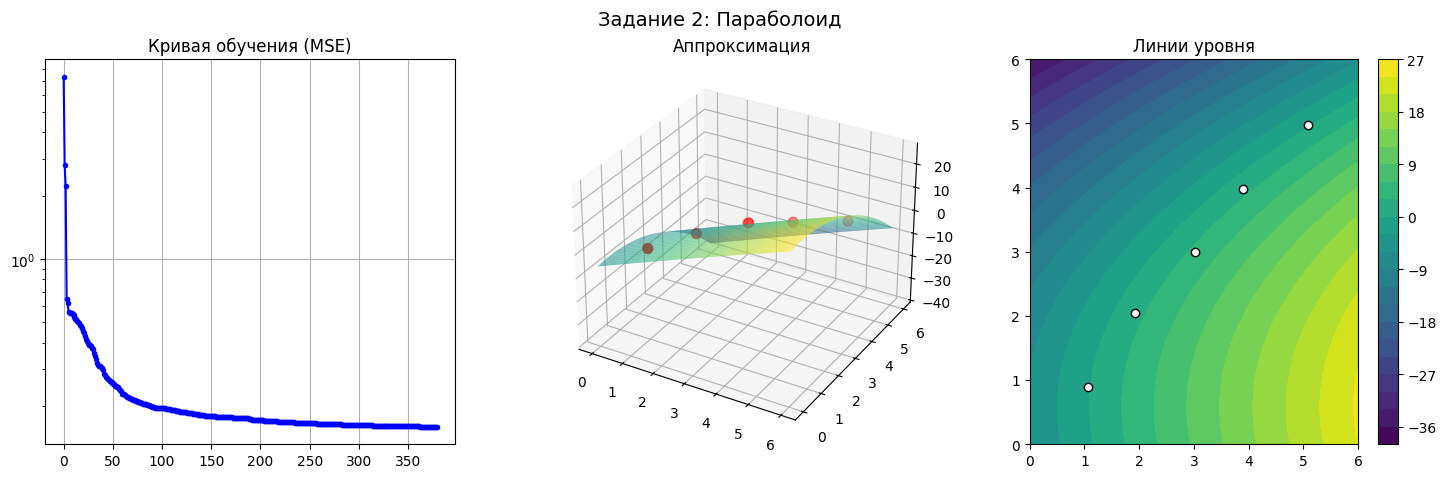

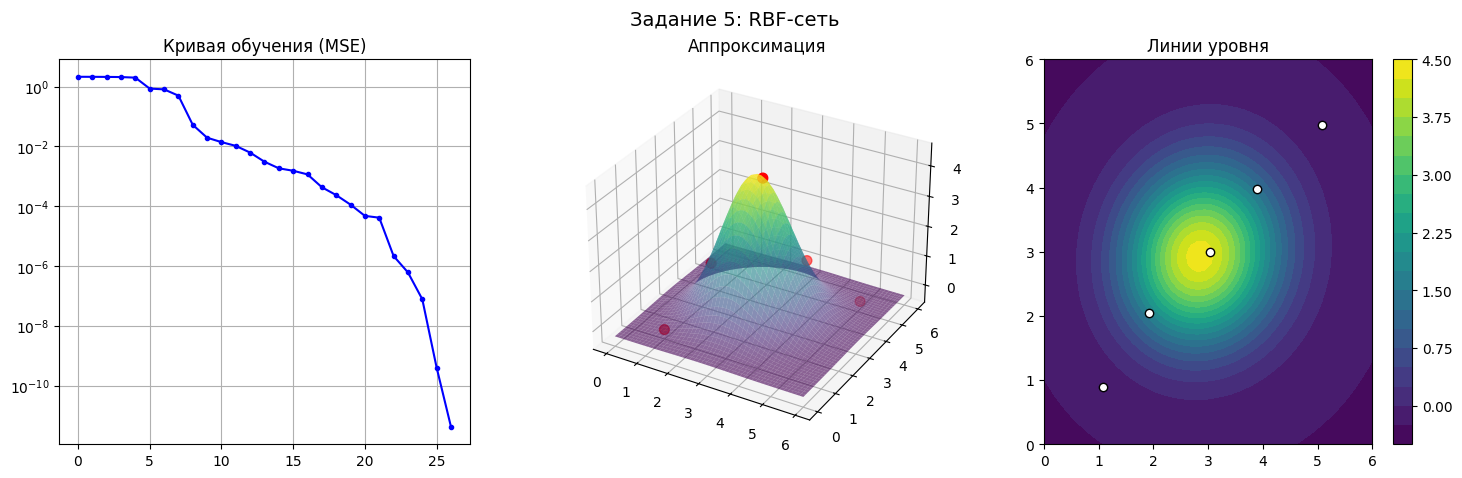

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Данные Варианта 13
X_d = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y_d = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z_d = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])


def plot_all(title, history, model_func, params, X, Y, Z):
    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(title, fontsize=14)

    # 1. Кривая обучения (теперь плавная)
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(history, "b-o", markersize=3)
    ax1.set_title("Кривая обучения (MSE)")
    ax1.set_yscale("log")
    ax1.grid(True)

    # Сетка для поверхностей
    mx, my = np.meshgrid(np.linspace(0, 6, 50), np.linspace(0, 6, 50))
    mz = model_func((mx, my), params)

    # 2. 3D Поверхность
    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    ax2.plot_surface(mx, my, mz, cmap="viridis", alpha=0.6)
    ax2.scatter(X, Y, Z, color="red", s=50)
    ax2.set_title("Аппроксимация")

    # 3. Линии уровня 
    ax3 = fig.add_subplot(1, 3, 3)
    cnt = ax3.contourf(mx, my, mz, levels=20, cmap="viridis")
    plt.colorbar(cnt)
    ax3.scatter(X, Y, color="white", edgecolors="black")
    ax3.set_title("Линии уровня")
    plt.show()


# --- ЗАДАНИЕ 2: ПАРАБОЛОИД ---
history_p = []


def model_p(xy, p):
    return p[0] * (xy[0] - p[2]) ** 2 + p[1] * (xy[1] - p[3]) ** 2 + p[4]


def loss_p(p):
    res = np.mean((model_p((X_d, Y_d), p) - Z_d) ** 2)
    return res


def cb_p(p):
    history_p.append(loss_p(p))


res_p = minimize(loss_p, [1.0, 1.0, 3.0, 3.0, 1.0], callback=cb_p, method="L-BFGS-B")

# --- ЗАДАНИЕ 5: RBF-СЕТЬ  ---
history_r = []


def model_r(xy, p):
    # w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2
    phi1 = np.exp(-p[5] * ((xy[0] - p[3]) ** 2 + (xy[1] - p[4]) ** 2))
    phi2 = np.exp(-p[8] * ((xy[0] - p[6]) ** 2 + (xy[1] - p[7]) ** 2))
    return p[0] + p[1] * phi1 + p[2] * phi2


def loss_r(p):
    return np.mean((model_r((X_d, Y_d), p) - Z_d) ** 2)


def cb_r(p):
    history_r.append(loss_r(p))


# Начальное приближение на основе К-средних
init_r = [0.0, 1.0, 1.0, 1.5, 1.5, 0.1, 4.0, 4.0, 0.1]
res_r = minimize(loss_r, init_r, callback=cb_r, method="L-BFGS-B")

# Отрисовка
plot_all("Задание 2: Параболоид", history_p, model_p, res_p.x, X_d, Y_d, Z_d)
plot_all("Задание 5: RBF-сеть", history_r, model_r, res_r.x, X_d, Y_d, Z_d)

РЕЗУЛЬТАТЫ ЗАДАНИЯ 2 (Параболоид)
Оптимальные параметры [a, b, x0, y0, c]:
[-1.08084665e-01 -1.19766535e+00  4.69851984e+01 -9.90152424e-01
  2.32034737e+02]

Аналитический вид:
z = -0.1081*(x - 46.9852)^2 + -1.1977*(y - -0.9902)^2 + 232.0347

Невязки на объектах:
 Точка 1: 0.116342
 Точка 2: -0.230850
 Точка 3: -0.074216
 Точка 4: 0.355088
 Точка 5: -0.164345
Итоговый MSE: 0.045086

РЕЗУЛЬТАТЫ ЗАДАНИЯ 5 (RBF-сеть)
Параметры [w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2]:
[-0.2556857   2.06059737  2.92716407  2.55270218  2.70010635  0.66879425
  3.0915073   3.12476737  0.53492665]

Аналитический вид:
z = -0.2557 + 2.0606*exp(-0.6688*dist1^2) + 2.9272*exp(-0.5349*dist2^2)

Невязки на объектах:
 Точка 1: -0.000001
 Точка 2: -0.000001
 Точка 3: 0.000004
 Точка 4: 0.000001
 Точка 5: -0.000001
Итоговый MSE: 0.000000


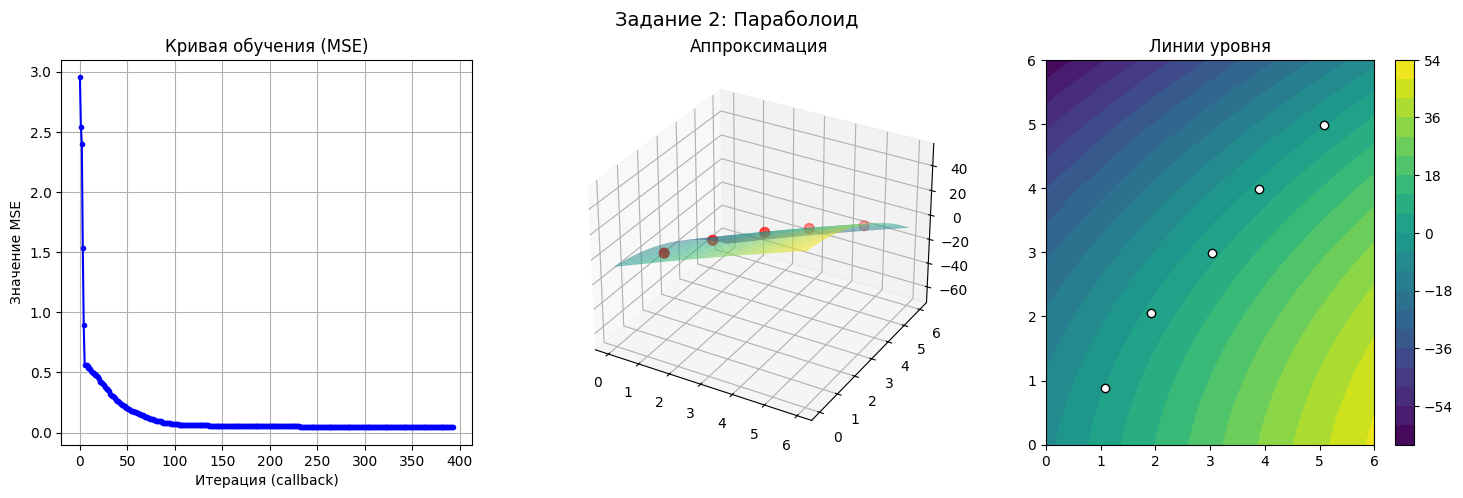

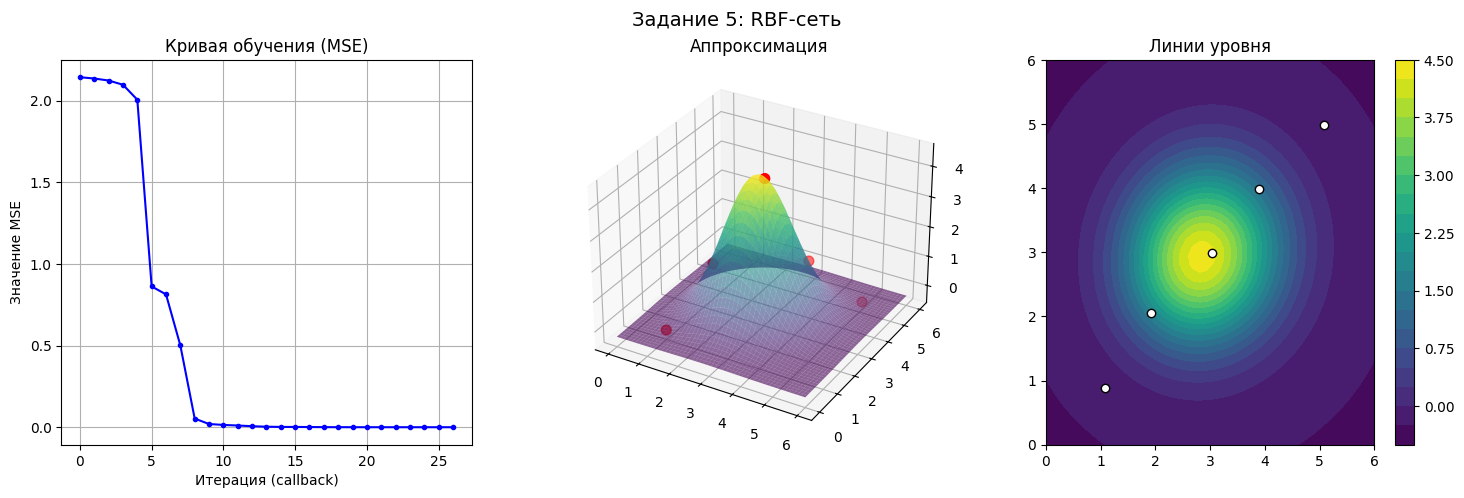

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Данные Варианта 13
X_d = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y_d = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z_d = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])


def plot_all(title, history, model_func, params, X, Y, Z):
    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(title, fontsize=14)

    # 1. Кривая обучения
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(history, "b-o", markersize=3)
    ax1.set_title("Кривая обучения (MSE)")
    ax1.set_xlabel("Итерация (callback)")
    ax1.set_ylabel("Значение MSE")
    ax1.grid(True)

    # Сетка для поверхностей
    mx, my = np.meshgrid(np.linspace(0, 6, 50), np.linspace(0, 6, 50))
    mz = model_func((mx, my), params)

    # 2. 3D Поверхность
    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    ax2.plot_surface(mx, my, mz, cmap="viridis", alpha=0.6)
    ax2.scatter(X, Y, Z, color="red", s=50, label="Исходные данные")
    ax2.set_title("Аппроксимация")

    # 3. Линии уровня
    ax3 = fig.add_subplot(1, 3, 3)
    cnt = ax3.contourf(mx, my, mz, levels=20, cmap="viridis")
    plt.colorbar(cnt)
    ax3.scatter(X, Y, color="white", edgecolors="black")
    ax3.set_title("Линии уровня")
    plt.show()


# --- ЗАДАНИЕ 2: ПАРАБОЛОИД ---
history_p = []


def model_p(xy, p):
    return p[0] * (xy[0] - p[2]) ** 2 + p[1] * (xy[1] - p[3]) ** 2 + p[4]


def loss_p(p):
    return np.mean((model_p((X_d, Y_d), p) - Z_d) ** 2)


def cb_p(p):
    history_p.append(loss_p(p))


# Начальное приближение [a, b, x0, y0, c]
init_p = [0.5, 0.5, 3.0, 3.0, 1.0]
res_p = minimize(loss_p, init_p, callback=cb_p, method="L-BFGS-B")

# --- ЗАДАНИЕ 5: RBF-СЕТЬ (Стратегия 2) ---
history_r = []


def model_r(xy, p):
    # p: [w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2]
    phi1 = np.exp(-p[5] * ((xy[0] - p[3]) ** 2 + (xy[1] - p[4]) ** 2))
    phi2 = np.exp(-p[8] * ((xy[0] - p[6]) ** 2 + (xy[1] - p[7]) ** 2))
    return p[0] + p[1] * phi1 + p[2] * phi2


def loss_r(p):
    return np.mean((model_r((X_d, Y_d), p) - Z_d) ** 2)


def cb_r(p):
    history_r.append(loss_r(p))


# Начальное приближение: веса, центры (1.5, 1.5) и (4.0, 4.0), малая бета
init_r = [0.0, 1.0, 1.0, 1.5, 1.5, 0.1, 4.0, 4.0, 0.1]
res_r = minimize(loss_r, init_r, callback=cb_r, method="L-BFGS-B")

# =====================================================
# ВЫВОД РЕЗУЛЬТАТОВ
# =====================================================

print("=" * 30)
print("РЕЗУЛЬТАТЫ ЗАДАНИЯ 2 (Параболоид)")
print("=" * 30)
p_opt = res_p.x
print(f"Оптимальные параметры [a, b, x0, y0, c]:\n{p_opt}")
print(f"\nАналитический вид:")
print(
    f"z = {p_opt[0]:.4f}*(x - {p_opt[2]:.4f})^2 + {p_opt[1]:.4f}*(y - {p_opt[3]:.4f})^2 + {p_opt[4]:.4f}"
)

z_p_pred = model_p((X_d, Y_d), p_opt)
resid_p = z_p_pred - Z_d
print(f"\nНевязки на объектах:")
for i, r in enumerate(resid_p):
    print(f" Точка {i+1}: {r:.6f}")
print(f"Итоговый MSE: {res_p.fun:.6f}")

print("\n" + "=" * 30)
print("РЕЗУЛЬТАТЫ ЗАДАНИЯ 5 (RBF-сеть)")
print("=" * 30)
r_opt = res_r.x
print(f"Параметры [w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2]:\n{r_opt}")
print(f"\nАналитический вид:")
print(
    f"z = {r_opt[0]:.4f} + {r_opt[1]:.4f}*exp(-{r_opt[5]:.4f}*dist1^2) + {r_opt[2]:.4f}*exp(-{r_opt[8]:.4f}*dist2^2)"
)

z_r_pred = model_r((X_d, Y_d), r_opt)
resid_r = z_r_pred - Z_d
print(f"\nНевязки на объектах:")
for i, r in enumerate(resid_r):
    print(f" Точка {i+1}: {r:.6f}")
print(f"Итоговый MSE: {res_r.fun:.6f}")

# Отрисовка графиков
plot_all("Задание 2: Параболоид", history_p, model_p, res_p.x, X_d, Y_d, Z_d)
plot_all("Задание 5: RBF-сеть", history_r, model_r, res_r.x, X_d, Y_d, Z_d)

=== РЕЗУЛЬТАТЫ ЗАДАНИЯ 2 ===
Параметры [a, b, x0, y0, c]: [-1.08084665e-01 -1.19766535e+00  4.69851984e+01 -9.90152424e-01
  2.32034737e+02]
MSE: 0.045086
Невязки: [ 0.11634177 -0.23084954 -0.07421566  0.35508826 -0.16434542]


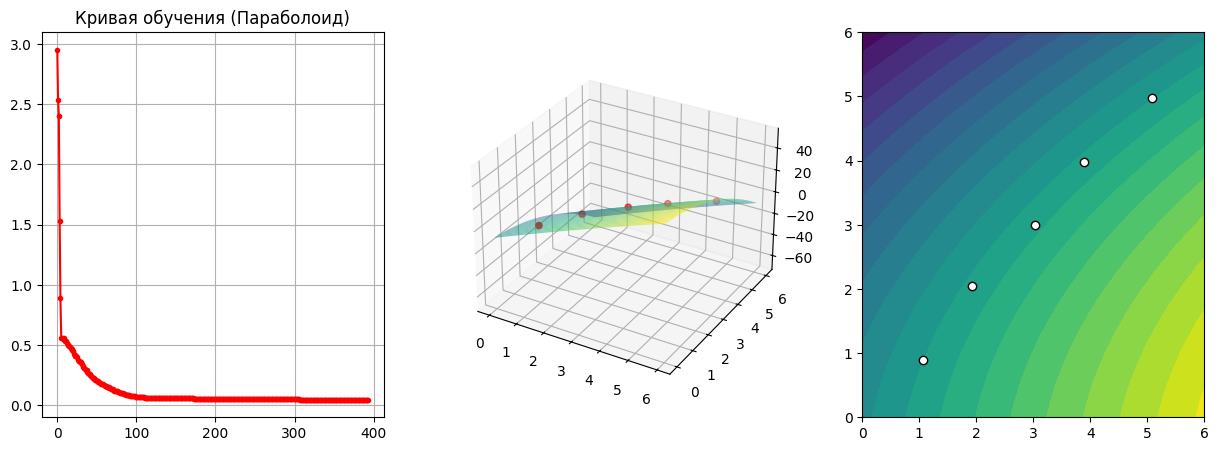

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Данные Варианта 13
X_d = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y_d = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z_d = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])


def model_p(xy, p):
    # Уравнение: a(x-x0)^2 + b(y-y0)^2 + c
    return p[0] * (xy[0] - p[2]) ** 2 + p[1] * (xy[1] - p[3]) ** 2 + p[4]


history_p = []


def loss_p(p):
    mse = np.mean((model_p((X_d, Y_d), p) - Z_d) ** 2)
    return mse


def cb_p(p):
    history_p.append(loss_p(p))


# Оптимизация
init_p = [0.5, 0.5, 3.0, 3.0, 1.0]
res_p = minimize(loss_p, init_p, callback=cb_p, method="L-BFGS-B")
p_opt = res_p.x

# Вывод результатов
print("=== РЕЗУЛЬТАТЫ ЗАДАНИЯ 2 ===")
print(f"Параметры [a, b, x0, y0, c]: {p_opt}")
print(f"MSE: {res_p.fun:.6f}")
print("Невязки:", model_p((X_d, Y_d), p_opt) - Z_d)

# Визуализация
fig = plt.figure(figsize=(15, 5))
# 1. Кривая обучения
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(history_p, "r-o", markersize=3)
ax1.set_title("Кривая обучения (Параболоид)")
ax1.grid(True)

# 2. Поверхность
mx, my = np.meshgrid(np.linspace(0, 6, 50), np.linspace(0, 6, 50))
mz = model_p((mx, my), p_opt)
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(mx, my, mz, cmap="viridis", alpha=0.6)
ax2.scatter(X_d, Y_d, Z_d, color="red")

# 3. Линии уровня
ax3 = fig.add_subplot(1, 3, 3)
ax3.contourf(mx, my, mz, levels=20, cmap="viridis")
ax3.scatter(X_d, Y_d, color="white", edgecolors="black")
plt.show()

=== РЕЗУЛЬТАТЫ ЗАДАНИЯ 5 ===
Параметры: [-0.2556857   2.06059737  2.92716407  2.55270218  2.70010635  0.66879425
  3.0915073   3.12476737  0.53492665]
MSE: 0.000000
Невязки: [-1.01283235e-06 -1.28641166e-06  3.94379420e-06  1.47250695e-06
 -8.80192670e-07]


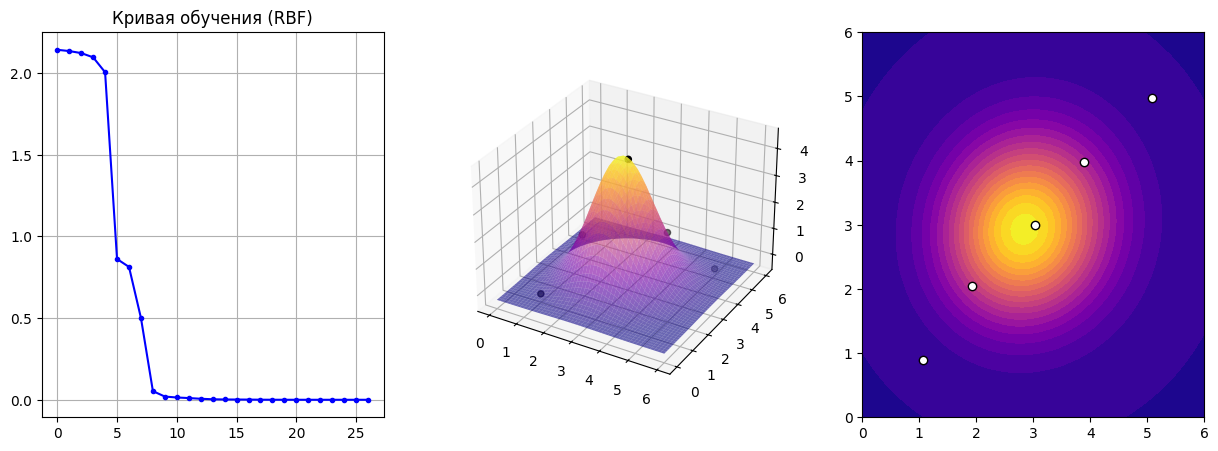

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Данные Варианта 13
X_d = np.array([1.07, 1.92, 3.03, 3.89, 5.09])
Y_d = np.array([0.89, 2.05, 2.99, 3.98, 4.98])
Z_d = np.array([-0.18, 1.69, 4.31, 1.36, -0.20])


def model_r(xy, p):
    # p: [w0, w1, w2, c1x, c1y, b1, c2x, c2y, b2]
    phi1 = np.exp(-p[5] * ((xy[0] - p[3]) ** 2 + (xy[1] - p[4]) ** 2))
    phi2 = np.exp(-p[8] * ((xy[0] - p[6]) ** 2 + (xy[1] - p[7]) ** 2))
    return p[0] + p[1] * phi1 + p[2] * phi2


history_r = []


def loss_r(p):
    mse = np.mean((model_r((X_d, Y_d), p) - Z_d) ** 2)
    return mse


def cb_r(p):
    history_r.append(loss_r(p))


# Начальное приближение на основе К-средних (Задание 4.1)
init_r = [0.0, 1.0, 1.0, 1.5, 1.5, 0.1, 4.0, 4.0, 0.1]
res_r = minimize(loss_r, init_r, callback=cb_r, method="L-BFGS-B")
r_opt = res_r.x

# Вывод результатов
print("=== РЕЗУЛЬТАТЫ ЗАДАНИЯ 5 ===")
print(f"Параметры: {r_opt}")
print(f"MSE: {res_r.fun:.6f}")
print("Невязки:", model_r((X_d, Y_d), r_opt) - Z_d)

# Визуализация
fig = plt.figure(figsize=(15, 5))
# 1. Кривая обучения
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(history_r, "b-o", markersize=3)
ax1.set_title("Кривая обучения (RBF)")
ax1.grid(True)

# 2. Поверхность
mx, my = np.meshgrid(np.linspace(0, 6, 50), np.linspace(0, 6, 50))
mz = model_r((mx, my), r_opt)
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(mx, my, mz, cmap="plasma", alpha=0.6)
ax2.scatter(X_d, Y_d, Z_d, color="black")

# 3. Линии уровня
ax3 = fig.add_subplot(1, 3, 3)
ax3.contourf(mx, my, mz, levels=20, cmap="plasma")
ax3.scatter(X_d, Y_d, color="white", edgecolors="black")
plt.show()